# E-Commerce Intelligence Platform

### 1_ Import Libraries (Toolkit)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2_ Load Raw Data


In [22]:
customers_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_customers_dataset.csv")
geolocation_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_geolocation_dataset.csv")
order_items_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_order_items_dataset.csv")
order_payments_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_order_payments_dataset.csv")
orders_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_orders_dataset.csv")
product_category_translation_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\product_category_name_translation.csv")
products_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_products_dataset.csv")
reviews_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_order_reviews_dataset.csv")
sellers_df = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\olist_sellers_dataset.csv")

### 3_ Dataset Inspection

#### Customers data (customers_df)

In [23]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [24]:
customers_df.shape

(99441, 5)

In [25]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [7]:
customers_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_14320\1449948072.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers_df.describe(include='object')


,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


In [10]:
customers_df['customer_city'].value_counts(normalize=True, dropna=False).mul(100).round(2)

customer_city
sao paulo              15.63
rio de janeiro          6.92
belo horizonte          2.79
brasilia                2.14
curitiba                1.53
                       ...  
siriji                  0.00
natividade da serra     0.00
monte bonito            0.00
sao rafael              0.00
eugenio de castro       0.00
Name: proportion, Length: 4119, dtype: float64

In [11]:
print(f"Unique Customers: {customers_df['customer_unique_id'].nunique():,} unique out of {len(customers_df):,} orders")

Unique Customers: 96,096 unique out of 99,441 orders


In [12]:
print("Duplicates:", customers_df.duplicated().sum())

Duplicates: 0


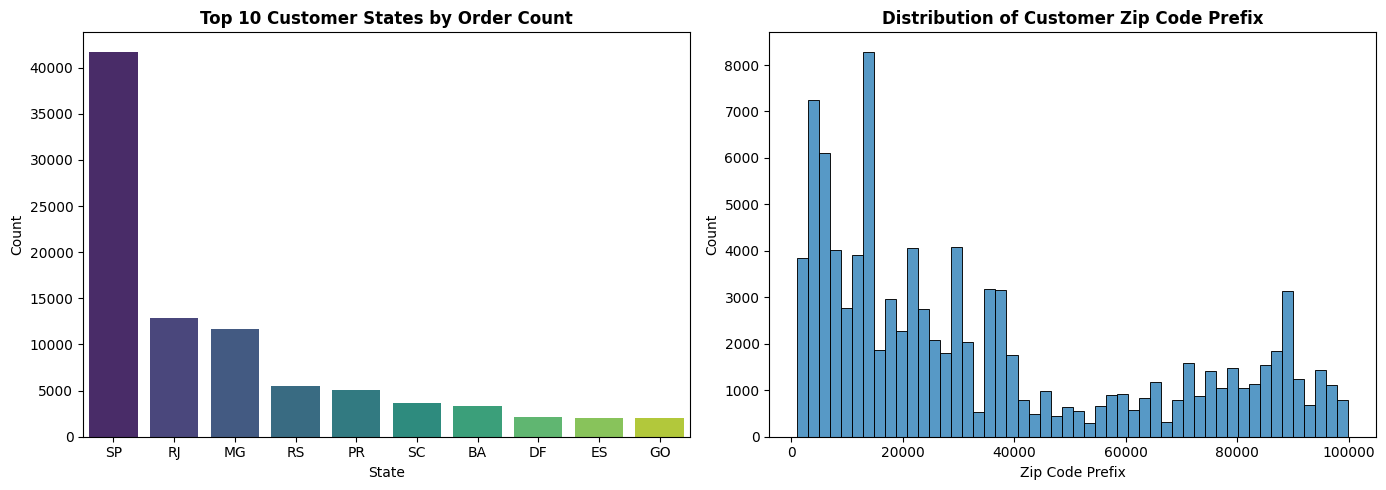

In [ ]:
# Visual Inspection: Top Customer States & Zip Code Distribution
fig, axes = plt.subplots(figsize=(14, 5))

top_states = customers_df['customer_state'].value_counts().head(10)
sns.barplot(x=top_states.index, y=top_states.values, palette='viridis', hue=top_states.index, legend=False, ax=axes[0])
axes[0].set_title("Top 10 Customer States by Order Count", fontsize=12, fontweight='bold')
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")

sns.histplot(customers_df['customer_zip_code_prefix'], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Distribution of Customer Zip Code Prefix", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Zip Code Prefix")

plt.tight_layout()
plt.show()


#### Geolocation data (geolocation_df)

In [14]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [15]:
geolocation_df.shape

(1000163, 5)

In [16]:
geolocation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB


In [17]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [18]:
geolocation_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_14320\2447851091.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  geolocation_df.describe(include='object')


,geolocation_city,geolocation_state
count,1000163,1000163
unique,8011,27
top,sao paulo,SP
freq,135800,404268


In [26]:
geolocation_df.nunique(dropna=True)

geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

In [ ]:
geolocation_df['geolocation_city'].value_counts(normalize=True, dropna=False).mul(100).round(2)

geolocation_city
sao paulo                     13.58
rio de janeiro                 6.21
belo horizonte                 2.78
são paulo                      2.49
curitiba                       1.66
                              ...  
são josé do herval             0.00
almirante tamandaré do sul     0.00
são valentim                   0.00
três arroios                   0.00
ciríaco                        0.00
Name: proportion, Length: 8011, dtype: float64

In [ ]:
geolocation_df['geolocation_state'].value_counts(normalize=True, dropna=False).mul(100).round(2)

geolocation_state
SP    40.42
MG    12.63
RJ    12.11
RS     6.18
PR     5.78
SC     3.83
BA     3.60
GO     2.01
ES     1.67
PE     1.64
DF     1.30
MT     1.20
CE     1.17
PA     1.09
MS     1.04
MA     0.79
PB     0.55
RN     0.50
PI     0.45
AL     0.42
TO     0.36
SE     0.36
RO     0.35
AM     0.24
AC     0.13
AP     0.09
RR     0.06
Name: proportion, dtype: float64

In [ ]:
print("Duplicates:",geolocation_df.duplicated().sum())

Duplicates: 261831


In [ ]:
print(f"Unique Zip Codes:",geolocation_df['geolocation_zip_code_prefix'].nunique())

Unique Zip Codes: 19015


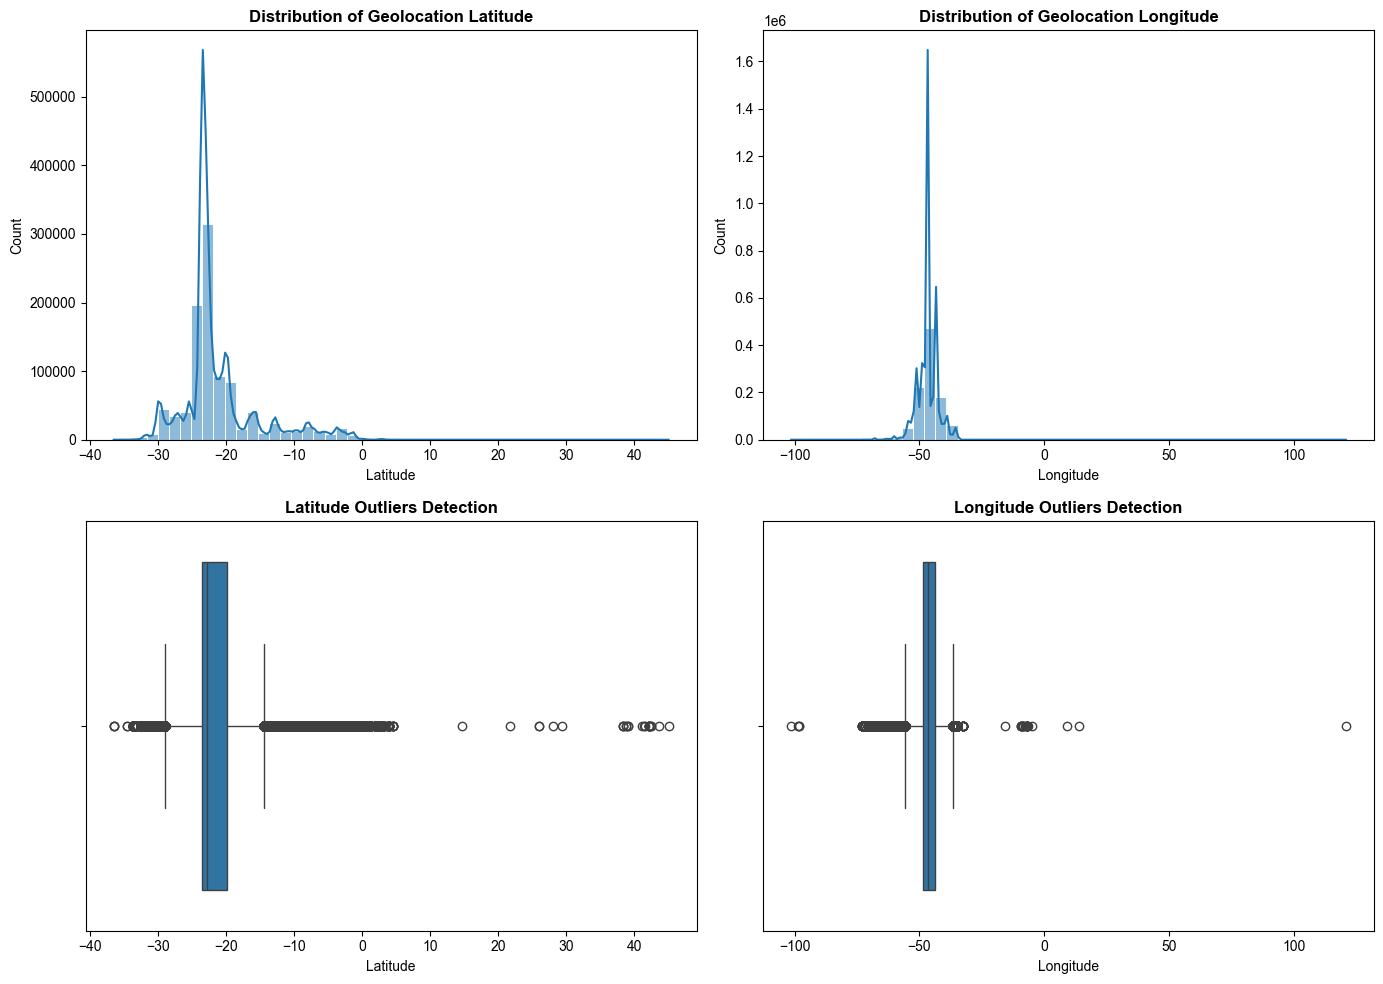

In [ ]:
# Visual Inspection: Distribution, Outliers & Correlation for Geolocation Coordinates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 1. Distributions (Histograms/KDE)
sns.histplot(geolocation_df['geolocation_lat'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Geolocation Latitude", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Latitude")

sns.histplot(geolocation_df['geolocation_lng'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Geolocation Longitude", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Longitude")

# 2. Outliers (Boxplots)
sns.boxplot(x=geolocation_df['geolocation_lat'], ax=axes[1, 0])
axes[1, 0].set_title("Latitude Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Latitude")

sns.boxplot(x=geolocation_df['geolocation_lng'], ax=axes[1, 1])
axes[1, 1].set_title("Longitude Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Longitude")

plt.tight_layout()
plt.show()



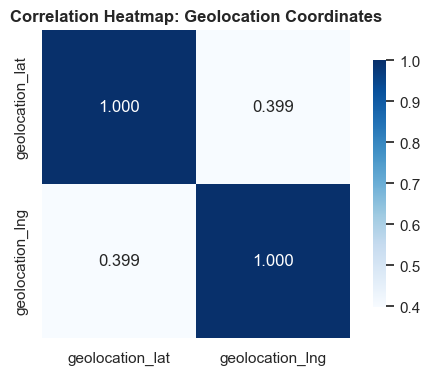

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(6, 4))
geo_corr = geolocation_df[['geolocation_lat', 'geolocation_lng']].corr()
sns.heatmap(geo_corr, annot=True, cmap='Blues', fmt='.3f', square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap: Geolocation Coordinates", fontsize=12, fontweight='bold')
plt.show()

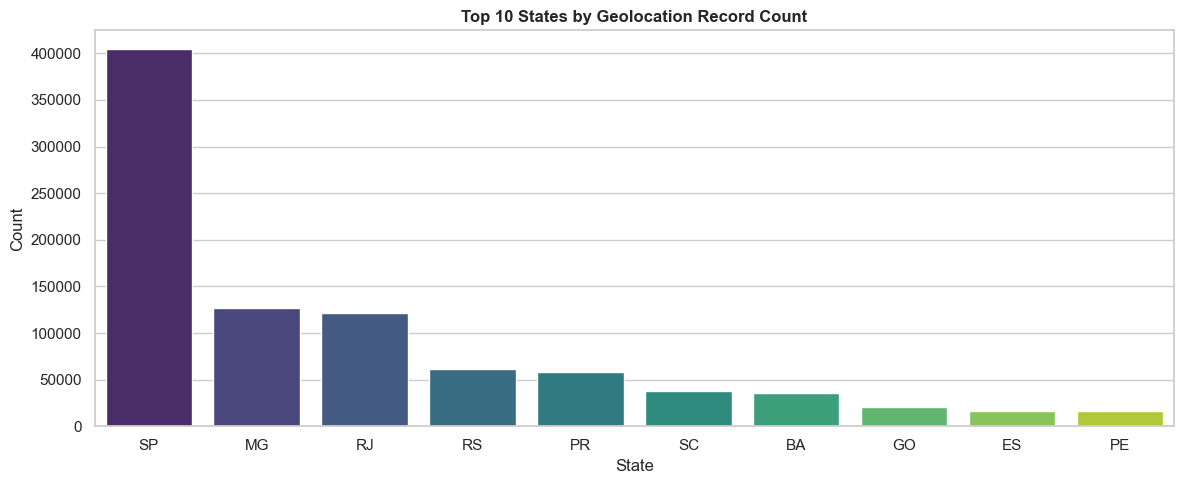

In [ ]:
# Visual Inspection: Top States by Geolocation Record Count
plt.figure(figsize=(12, 5))
top_geo_states = geolocation_df['geolocation_state'].value_counts().head(10)
sns.barplot(x=top_geo_states.index, y=top_geo_states.values, palette='viridis', hue=top_geo_states.index, legend=False)
plt.title("Top 10 States by Geolocation Record Count", fontsize=12, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Order Items data (order_items_df)

In [ ]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items_df.shape

(112650, 7)

In [ ]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:
order_items_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\4250554650.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  order_items_df.describe(include='object')


,order_id,product_id,seller_id,shipping_limit_date
count,112650,112650,112650,112650
unique,98666,32951,3095,93318
top,8272b63d03f5f79c56e9e4120aec44ef,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48
freq,21,527,2033,21


In [ ]:
order_items_df.nunique(dropna=True)

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [ ]:
print(f"Duplicates:",order_items_df.duplicated().sum())

Duplicates: 0


In [ ]:
order_items_df['seller_id'].value_counts(normalize=True, dropna=False).mul(100).round(2)

seller_id
6560211a19b47992c3666cc44a7e94c0    1.80
4a3ca9315b744ce9f8e9374361493884    1.76
1f50f920176fa81dab994f9023523100    1.71
cc419e0650a3c5ba77189a1882b7556a    1.58
da8622b14eb17ae2831f4ac5b9dab84a    1.38
                                    ... 
a1bea9970d8f65b240555f99c2214f7f    0.00
d1aa1ec0839dcab73a6161130eb1f94a    0.00
dbc51f5e45d654ecc16cb68e6817ecea    0.00
3fefda3299e6dfaea3466ef346a3571a    0.00
80ceebb4ee9b31afb6c6a916a574a1e2    0.00
Name: proportion, Length: 3095, dtype: float64

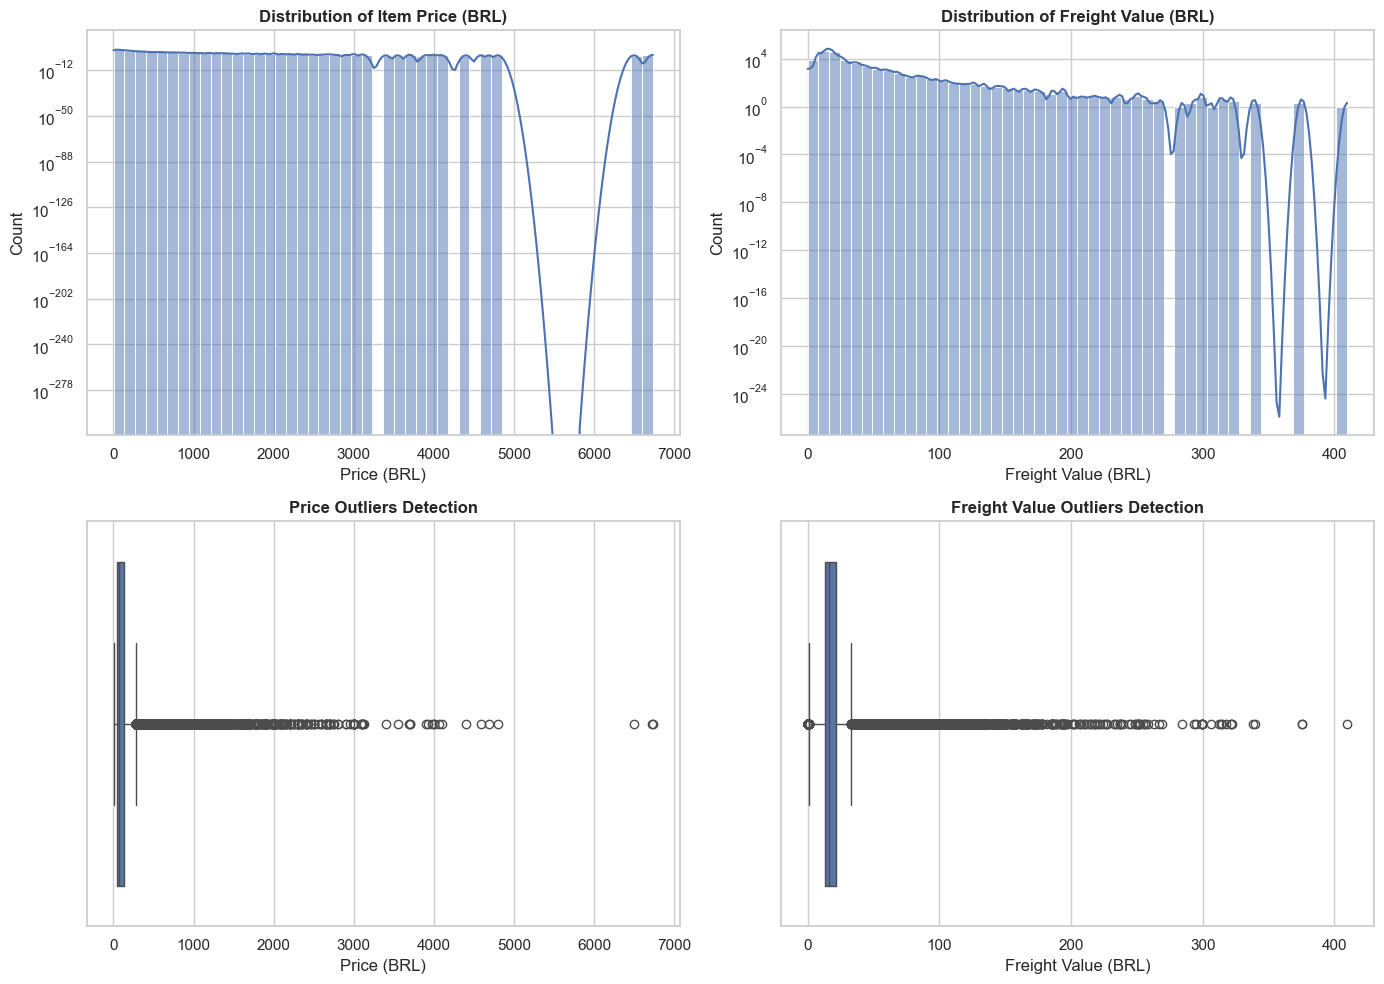

In [ ]:
# Visual Inspection: Distribution & Outliers for Price and Freight Value
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distributions
sns.histplot(order_items_df['price'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Item Price (BRL)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Price (BRL)")
axes[0, 0].set_yscale('log')  # Log scale due to heavy right skew

sns.histplot(order_items_df['freight_value'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Freight Value (BRL)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Freight Value (BRL)")
axes[0, 1].set_yscale('log')

# 2. Outliers (Boxplots)
sns.boxplot(x=order_items_df['price'], ax=axes[1, 0])
axes[1, 0].set_title("Price Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Price (BRL)")

sns.boxplot(x=order_items_df['freight_value'], ax=axes[1, 1])
axes[1, 1].set_title("Freight Value Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Freight Value (BRL)")

plt.tight_layout()
plt.show()

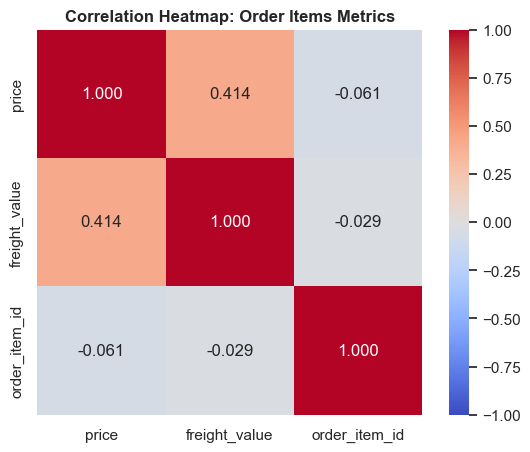

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(7, 5))
items_corr = order_items_df[['price', 'freight_value', 'order_item_id']].corr()
sns.heatmap(items_corr, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap: Order Items Metrics", fontsize=12, fontweight='bold')
plt.show()

In [ ]:
print(f"Unique Orders: {order_items_df['order_id'].nunique():,}")
print(f"Unique Products: {order_items_df['product_id'].nunique():,}")
print(f"Unique Sellers: {order_items_df['seller_id'].nunique():,}")

Unique Orders: 98,666
Unique Products: 32,951
Unique Sellers: 3,095


#### Order Payments data (order_payments_df)

In [ ]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments_df.shape

(103886, 5)

In [ ]:
order_payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [ ]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [ ]:
order_payments_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\1541781003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  order_payments_df.describe(include='object')


,order_id,payment_type
count,103886,103886
unique,99440,5
top,fa65dad1b0e818e3ccc5cb0e39231352,credit_card
freq,29,76795


In [ ]:
order_payments_df.nunique(dropna=True)

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

In [ ]:
print("Duplicates:", order_payments_df.duplicated().sum())

Duplicates: 0


In [ ]:
order_payments_df['payment_type'].value_counts(normalize=True, dropna=False).mul(100).round(2)

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

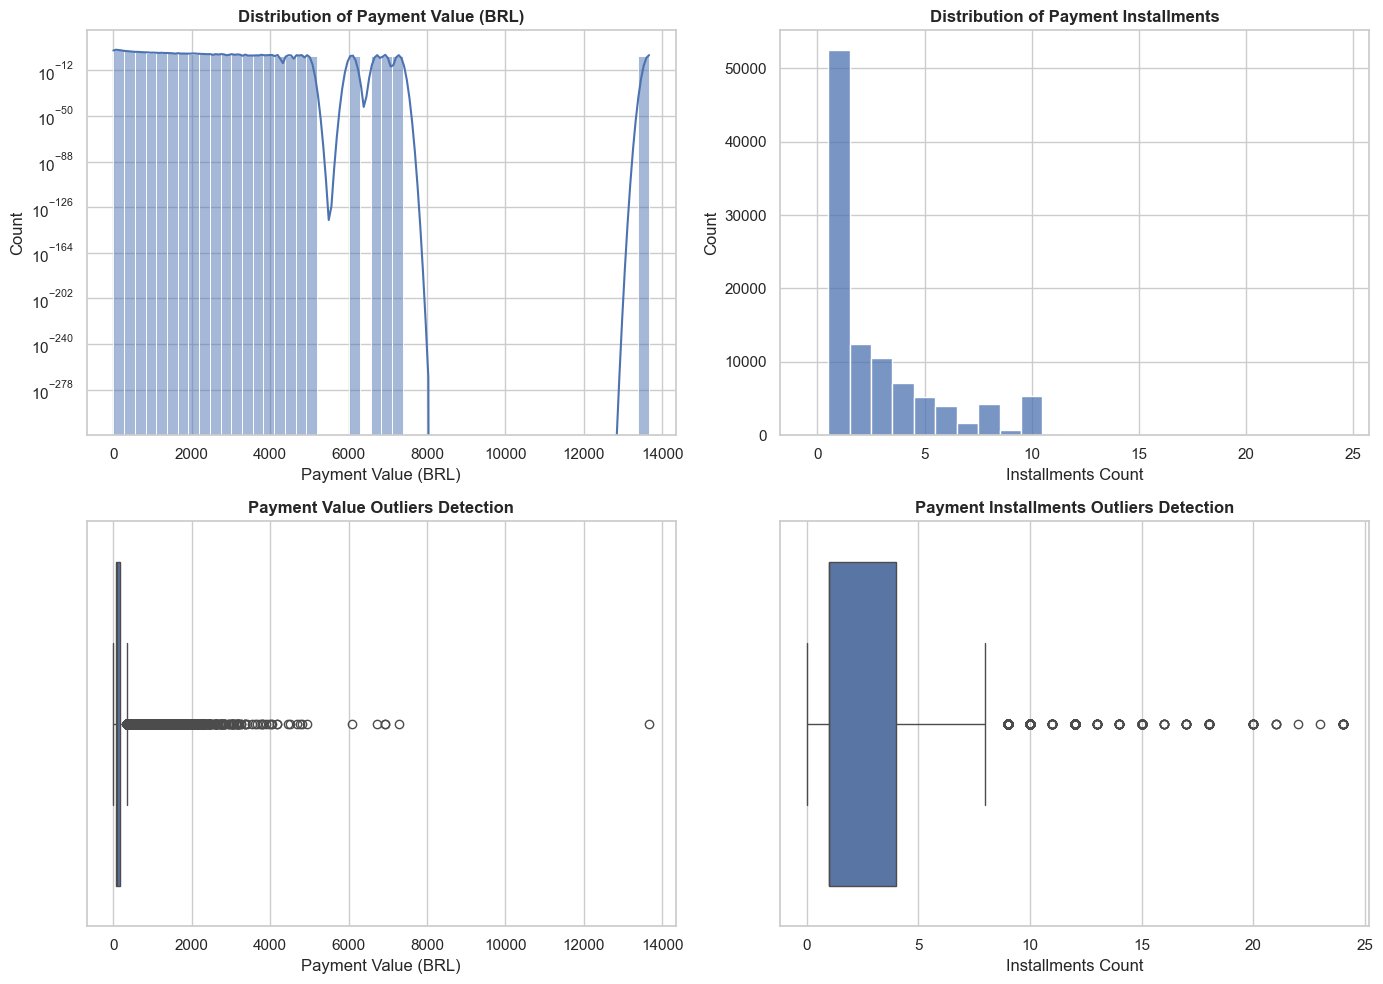

In [ ]:
# Visual Inspection: Distribution, Outliers & Correlation for Payments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distributions
sns.histplot(order_payments_df['payment_value'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Payment Value (BRL)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Payment Value (BRL)")
axes[0, 0].set_yscale('log')

sns.histplot(order_payments_df['payment_installments'], discrete=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Payment Installments", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Installments Count")

# 2. Outliers (Boxplots)
sns.boxplot(x=order_payments_df['payment_value'], ax=axes[1, 0])
axes[1, 0].set_title("Payment Value Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Payment Value (BRL)")

sns.boxplot(x=order_payments_df['payment_installments'], ax=axes[1, 1])
axes[1, 1].set_title("Payment Installments Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Installments Count")

plt.tight_layout()
plt.show()

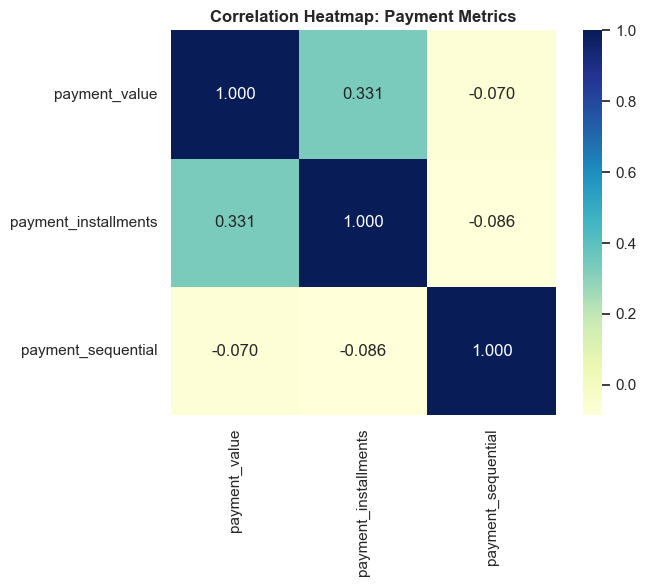

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(7, 5))
pay_corr = order_payments_df[['payment_value', 'payment_installments', 'payment_sequential']].corr()
sns.heatmap(pay_corr, annot=True, cmap='YlGnBu', fmt='.3f', square=True)
plt.title("Correlation Heatmap: Payment Metrics", fontsize=12, fontweight='bold')
plt.show()

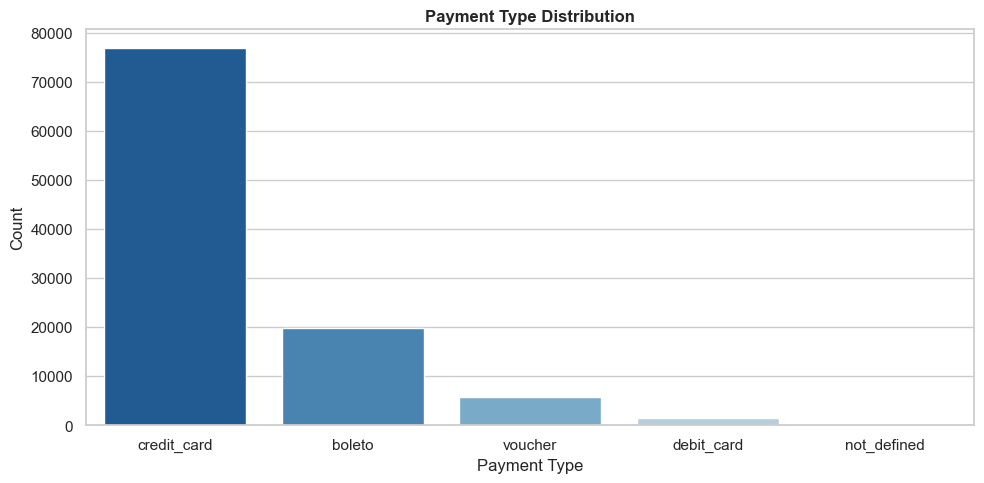

In [ ]:
# Visual Inspection: Payment Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='payment_type', data=order_payments_df,
              order=order_payments_df['payment_type'].value_counts().index, palette='Blues_r',
              hue='payment_type', legend=False)
plt.title("Payment Type Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Orders data (orders_df)

In [ ]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders_df.shape

(99441, 8)

In [ ]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [ ]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [ ]:
print("Duplicates: ",orders_df.duplicated().sum())

Duplicates:  0


In [ ]:
orders_df.nunique(dropna=True)

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [ ]:
orders_df['order_status'].value_counts(normalize=True, dropna=False).mul(100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

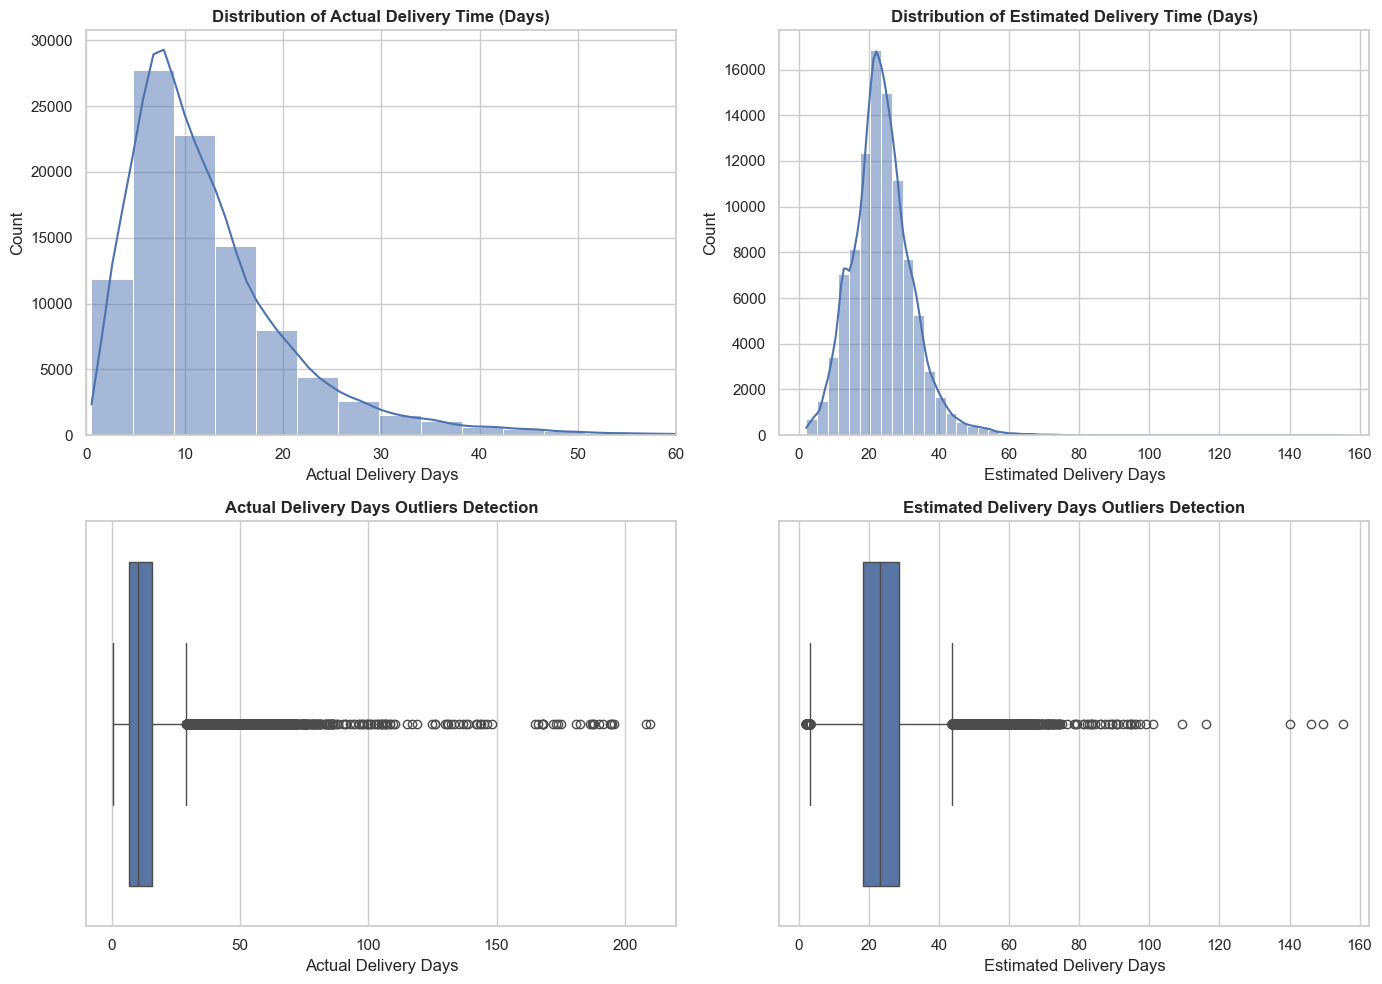

In [ ]:
# Calculate temporary delivery duration metrics in days for inspection
purch_dt = pd.to_datetime(orders_df['order_purchase_timestamp'], errors='coerce')
deliv_dt = pd.to_datetime(orders_df['order_delivered_customer_date'], errors='coerce')
estim_dt = pd.to_datetime(orders_df['order_estimated_delivery_date'], errors='coerce')

temp_orders_df = pd.DataFrame({
    'actual_delivery_days': (deliv_dt - purch_dt).dt.total_seconds() / (24 * 3600),
    'estimated_delivery_days': (estim_dt - purch_dt).dt.total_seconds() / (24 * 3600)
}).dropna()

# Visual Inspection: Distributions, Outliers & Correlation for Delivery Latencies
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distributions
sns.histplot(temp_orders_df['actual_delivery_days'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Actual Delivery Time (Days)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Actual Delivery Days")
axes[0, 0].set_xlim(0, 60)

sns.histplot(temp_orders_df['estimated_delivery_days'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Estimated Delivery Time (Days)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Estimated Delivery Days")

# 2. Outliers (Boxplots)
sns.boxplot(x=temp_orders_df['actual_delivery_days'], ax=axes[1, 0])
axes[1, 0].set_title("Actual Delivery Days Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Actual Delivery Days")

sns.boxplot(x=temp_orders_df['estimated_delivery_days'], ax=axes[1, 1])
axes[1, 1].set_title("Estimated Delivery Days Outliers Detection", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Estimated Delivery Days")

plt.tight_layout()
plt.show()

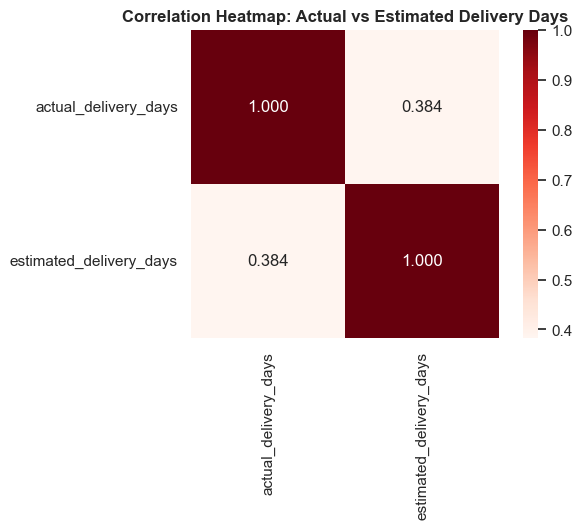

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(6, 4))
ord_corr = temp_orders_df[['actual_delivery_days', 'estimated_delivery_days']].corr()
sns.heatmap(ord_corr, annot=True, cmap='Reds', fmt='.3f', square=True)
plt.title("Correlation Heatmap: Actual vs Estimated Delivery Days", fontsize=12, fontweight='bold')
plt.show()

In [ ]:
# Note: the "Missing Count" cell above was copy-pasted from order_payments_df by mistake
# (it reuses order_payments_df instead of orders_df). This cell computes the correct
# missing-value counts for orders_df without touching the cell above.
missing_orders_df = orders_df.isnull().sum().to_frame('Missing Count')
missing_orders_df['Missing %'] = (orders_df.isnull().sum() / len(orders_df)) * 100
missing_orders_df


,Missing Count,Missing %
order_id,0,0.000000
customer_id,0,0.000000
order_status,0,0.000000
order_purchase_timestamp,0,0.000000
order_approved_at,160,0.160899
order_delivered_carrier_date,1783,1.793023
order_delivered_customer_date,2965,2.981668
order_estimated_delivery_date,0,0.000000


In [ ]:
orders_df.describe(include='object')


C:\Users\mario\AppData\Local\Temp\ipykernel_19076\2508468078.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  orders_df.describe(include='object')


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


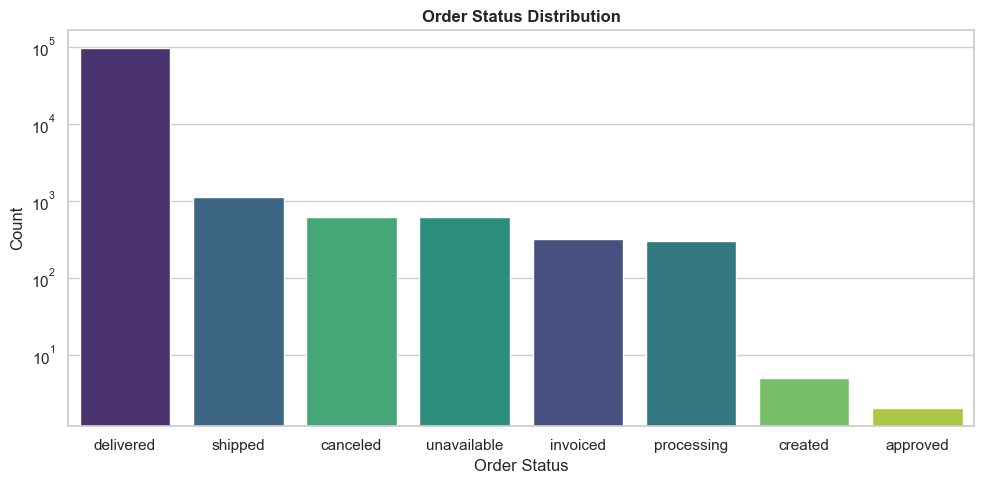

In [ ]:
# Visual Inspection: Order Status Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='order_status', data=orders_df,
              order=orders_df['order_status'].value_counts().index, palette='viridis',
              hue='order_status', legend=False)
plt.title("Order Status Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.yscale('log')
plt.tight_layout()
plt.show()


####  Product Category Translation data (product_category_translation_df)

In [ ]:
product_category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
product_category_translation_df.shape

(71, 2)

In [ ]:
product_category_translation_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [ ]:
product_category_translation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


In [ ]:
print("Duplicates:",product_category_translation_df.duplicated().sum())

Duplicates: 0


In [ ]:
print(f"Unique Portuguese Category Names: {product_category_translation_df['product_category_name'].nunique()}")
print(f"Unique English Category Names: {product_category_translation_df['product_category_name_english'].nunique()}")


Unique Portuguese Category Names: 71
Unique English Category Names: 71


#### Products data (products_df)

In [ ]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products_df.shape

(32951, 9)

In [ ]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [ ]:
print("Duplicates:",products_df.duplicated().sum())

Duplicates: 0


In [ ]:
products_df.nunique(dropna=True)

product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

In [ ]:
missing_products_df = products_df.isnull().sum().to_frame('Missing Count')
missing_products_df['Missing %'] = (products_df.isnull().sum() / len(products_df)) * 100
missing_products_df

,Missing Count,Missing %
product_id,0,0.000000
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\1834749247.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  products_df.describe(include='object')


,product_id,product_category_name
count,32951,32341
unique,32951,73
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho
freq,1,3029


In [ ]:
products_df['product_category_name'].value_counts(normalize=True, dropna=False).mul(100).round(2)

product_category_name
cama_mesa_banho                  9.19
esporte_lazer                    8.70
moveis_decoracao                 8.06
beleza_saude                     7.42
utilidades_domesticas            7.09
                                 ... 
fashion_roupa_infanto_juvenil    0.02
casa_conforto_2                  0.02
pc_gamer                         0.01
seguros_e_servicos               0.01
cds_dvds_musicais                0.00
Name: proportion, Length: 74, dtype: float64

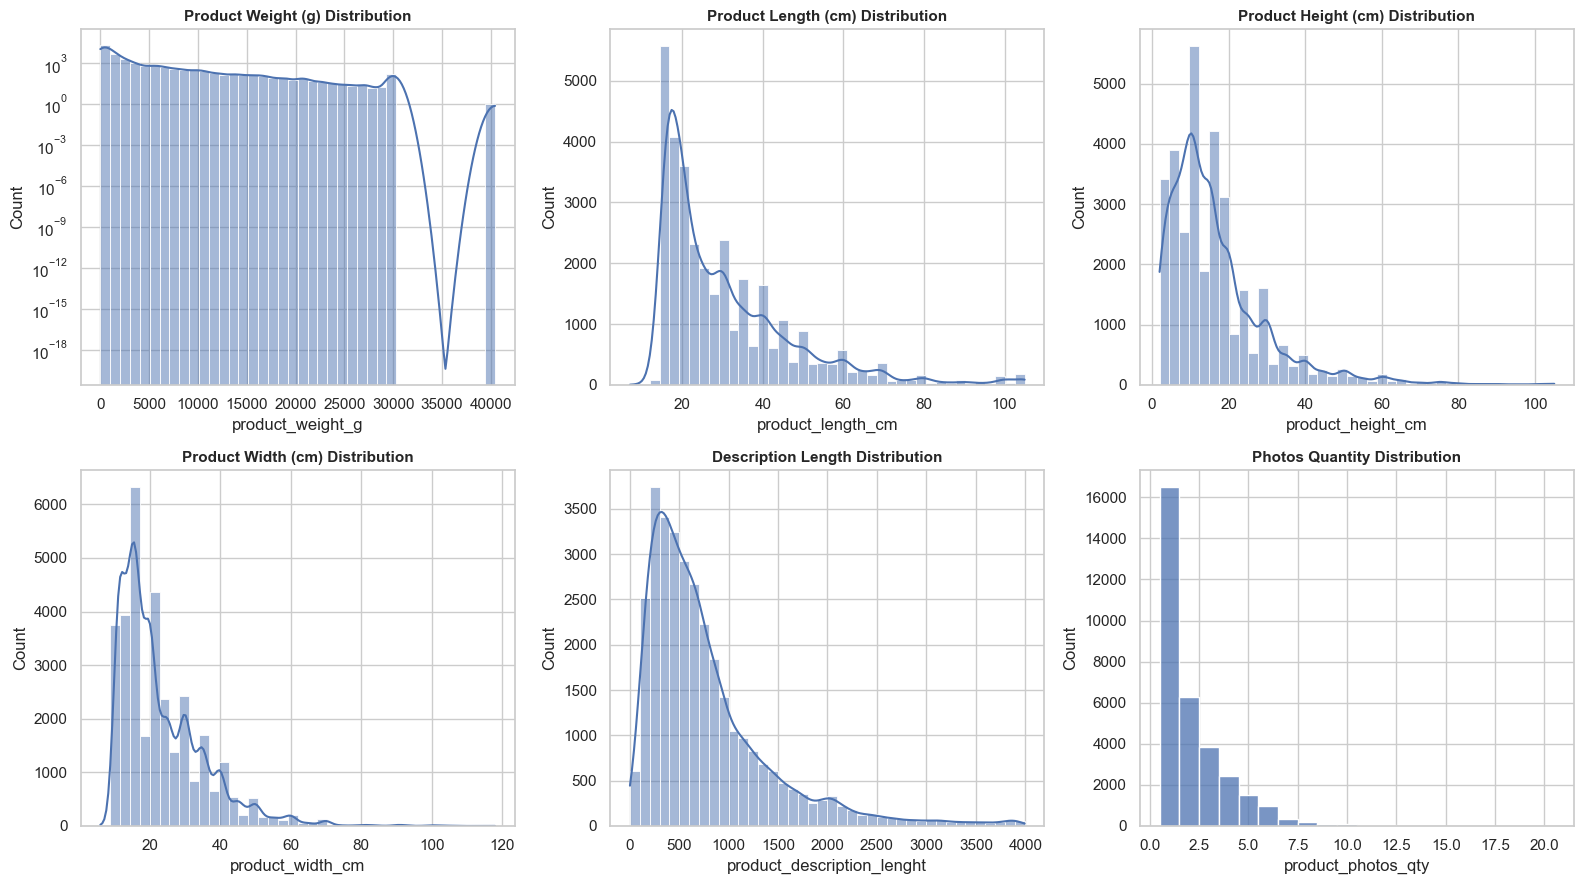

In [ ]:
# Visual Inspection: Distribution of Physical Dimensions & Content Metadata
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.set_theme(style="whitegrid")

sns.histplot(products_df['product_weight_g'], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Product Weight (g) Distribution", fontsize=11, fontweight='bold')
axes[0, 0].set_yscale('log')

sns.histplot(products_df['product_length_cm'], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Product Length (cm) Distribution", fontsize=11, fontweight='bold')

sns.histplot(products_df['product_height_cm'], bins=40, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Product Height (cm) Distribution", fontsize=11, fontweight='bold')

sns.histplot(products_df['product_width_cm'], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Product Width (cm) Distribution", fontsize=11, fontweight='bold')

sns.histplot(products_df['product_description_lenght'], bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Description Length Distribution", fontsize=11, fontweight='bold')

sns.histplot(products_df['product_photos_qty'], discrete=True, ax=axes[1, 2])
axes[1, 2].set_title("Photos Quantity Distribution", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

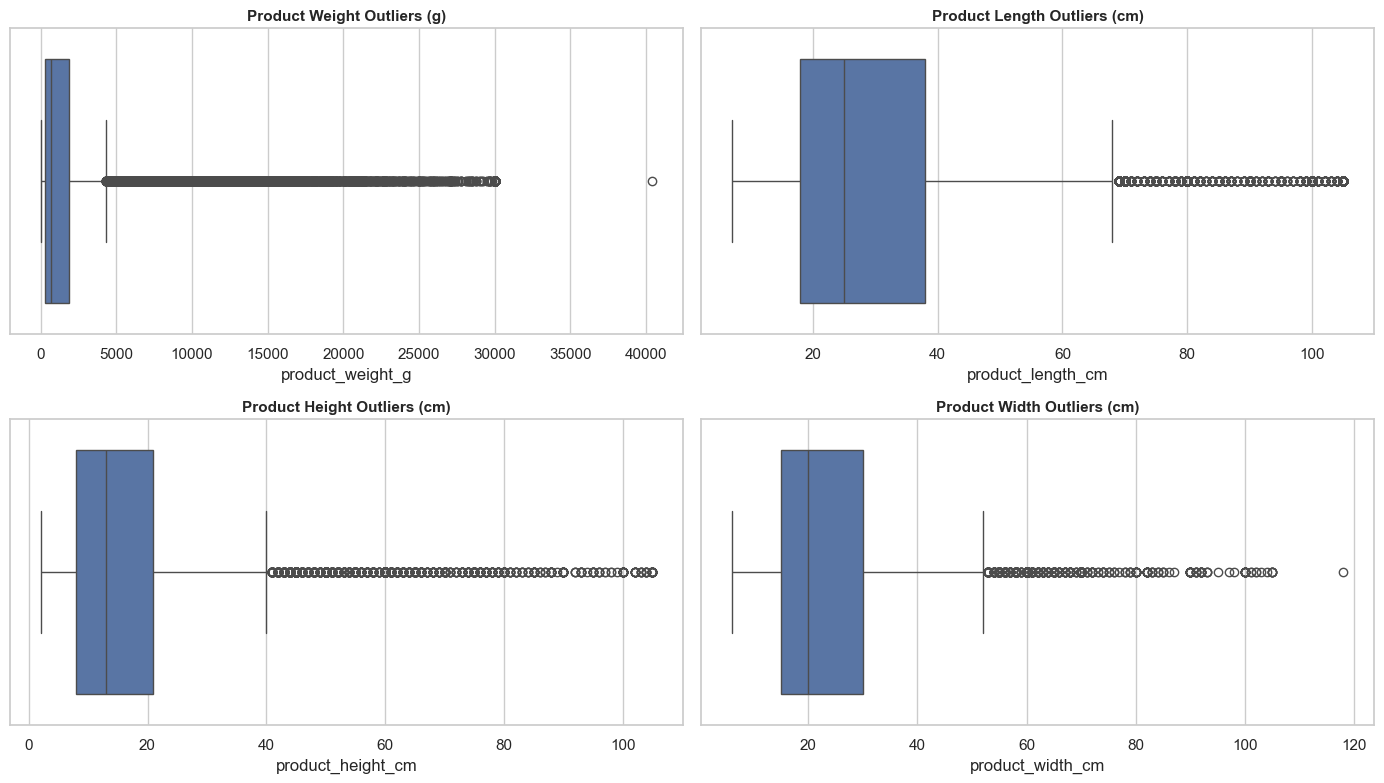

In [ ]:
# Visual Inspection: Outliers (Boxplots) for Products Specifications
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.boxplot(x=products_df['product_weight_g'], ax=axes[0, 0])
axes[0, 0].set_title("Product Weight Outliers (g)", fontsize=11, fontweight='bold')

sns.boxplot(x=products_df['product_length_cm'], ax=axes[0, 1])
axes[0, 1].set_title("Product Length Outliers (cm)", fontsize=11, fontweight='bold')

sns.boxplot(x=products_df['product_height_cm'], ax=axes[1, 0])
axes[1, 0].set_title("Product Height Outliers (cm)", fontsize=11, fontweight='bold')

sns.boxplot(x=products_df['product_width_cm'], ax=axes[1, 1])
axes[1, 1].set_title("Product Width Outliers (cm)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

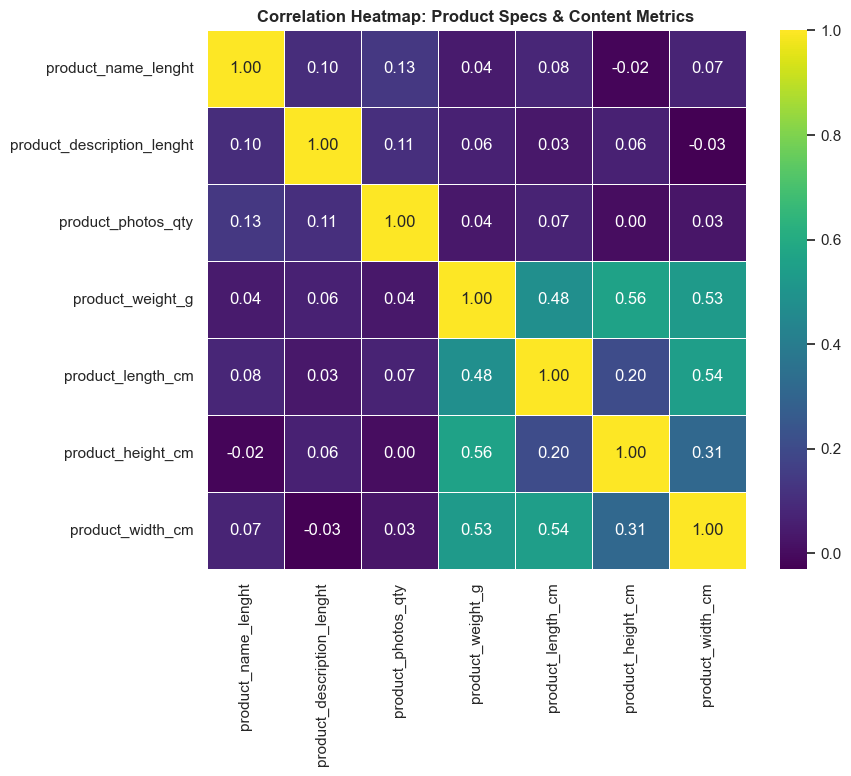

In [ ]:
# Correlation Heatmap for All Products Physical Specs & Attributes
plt.figure(figsize=(9, 7))
prod_corr = products_df[['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].corr()
sns.heatmap(prod_corr, annot=True, cmap='viridis', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Product Specs & Content Metrics", fontsize=12, fontweight='bold')
plt.show()

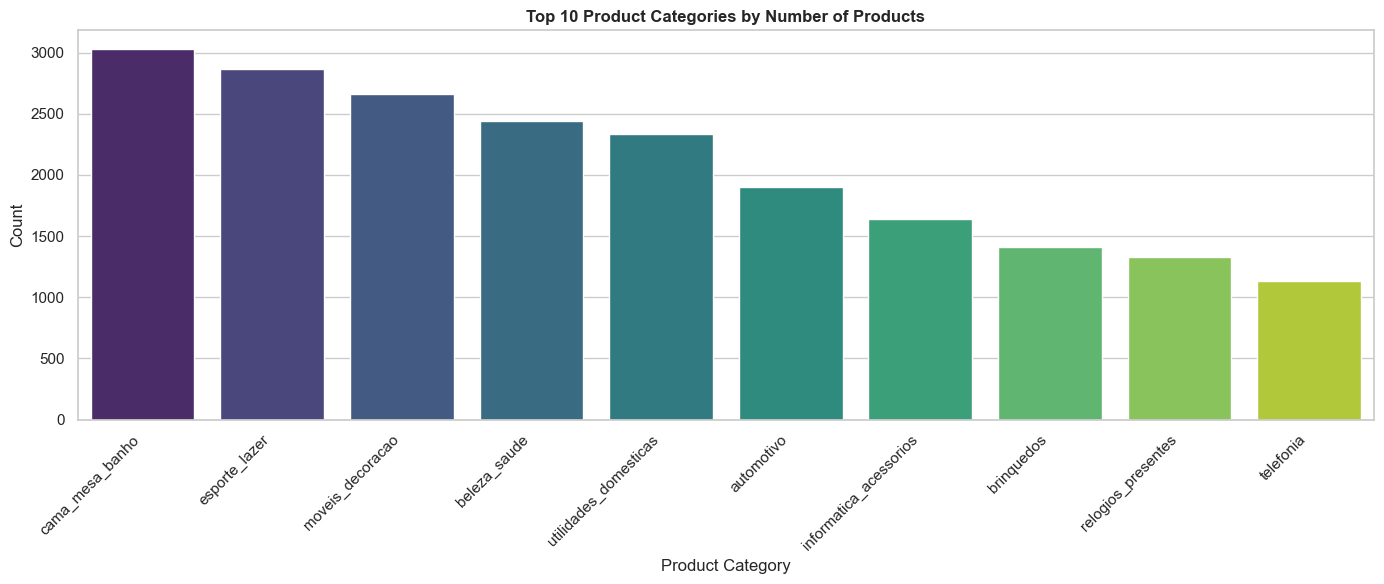

In [ ]:
# Visual Inspection: Top 10 Product Categories by Number of Products
plt.figure(figsize=(14, 6))
top_categories = products_df['product_category_name'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis', hue=top_categories.index, legend=False)
plt.title("Top 10 Product Categories by Number of Products", fontsize=12, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Reviews data (reviews_df)

In [ ]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
reviews_df.shape

(99224, 7)

In [ ]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [ ]:
reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
reviews_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\394727772.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  reviews_df.describe(include='object')


,review_id,order_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,11568,40977,99224,99224
unique,98410,98673,4527,36159,636,98248
top,c444278834184f72b1484dfe47de7f97,c88b1d1b157a9999ce368f218a407141,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,423,230,463,4


In [ ]:
print("Duplicates: ", reviews_df.duplicated().sum())

Duplicates:  0


In [ ]:
missing_reviews_df = reviews_df.isnull().sum().to_frame('Missing Count')
missing_reviews_df['Missing %'] = (reviews_df.isnull().sum() / len(reviews_df)) * 100
missing_reviews_df

,Missing Count,Missing %
review_id,0,0.000000
order_id,0,0.000000
review_score,0,0.000000
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532
review_creation_date,0,0.000000
review_answer_timestamp,0,0.000000


In [ ]:
reviews_df['review_score'].value_counts(normalize=True, dropna=False).mul(100).round(2).sort_index()

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\3080155370.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=temp_reviews_df['review_score'], ax=axes[0], palette='Blues_r')


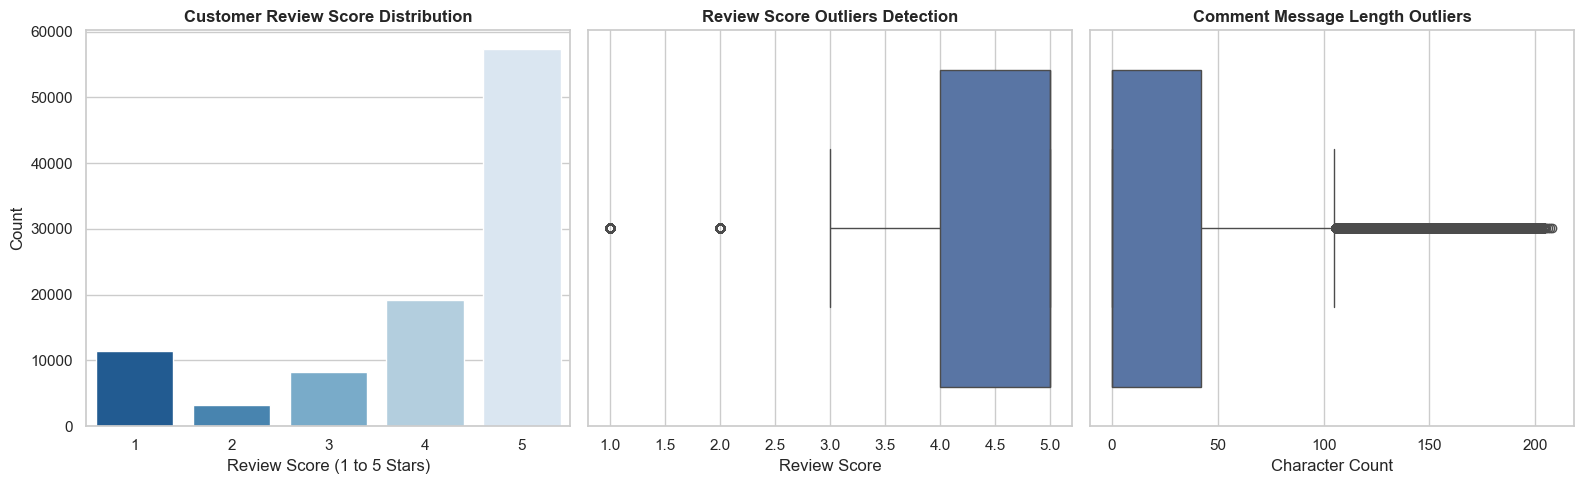

In [ ]:
temp_reviews_df = pd.DataFrame({
    'review_score': reviews_df['review_score'],
    'comment_length': reviews_df['review_comment_message'].fillna('').str.len()
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Rating Score Distribution
sns.countplot(x=temp_reviews_df['review_score'], ax=axes[0], palette='Blues_r')
axes[0].set_title("Customer Review Score Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Review Score (1 to 5 Stars)")
axes[0].set_ylabel("Count")

# 2. Score Outlier Boxplot
sns.boxplot(x=temp_reviews_df['review_score'], ax=axes[1])
axes[1].set_title("Review Score Outliers Detection", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Review Score")

# 3. Comment Length Boxplot
sns.boxplot(x=temp_reviews_df['comment_length'], ax=axes[2])
axes[2].set_title("Comment Message Length Outliers", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Character Count")

plt.tight_layout()
plt.show()

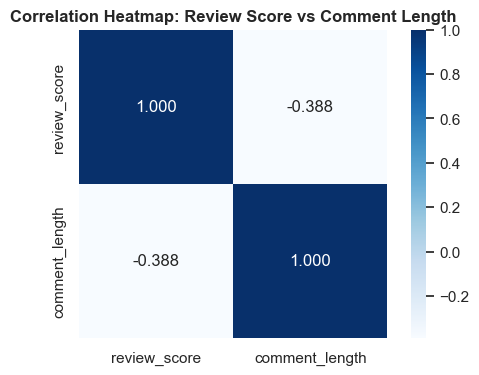

In [ ]:
# 4. Correlation Heatmap
plt.figure(figsize=(6, 4))
rev_corr = temp_reviews_df.corr()
sns.heatmap(rev_corr, annot=True, cmap='Blues', fmt='.3f', square=True)
plt.title("Correlation Heatmap: Review Score vs Comment Length", fontsize=12, fontweight='bold')
plt.show()

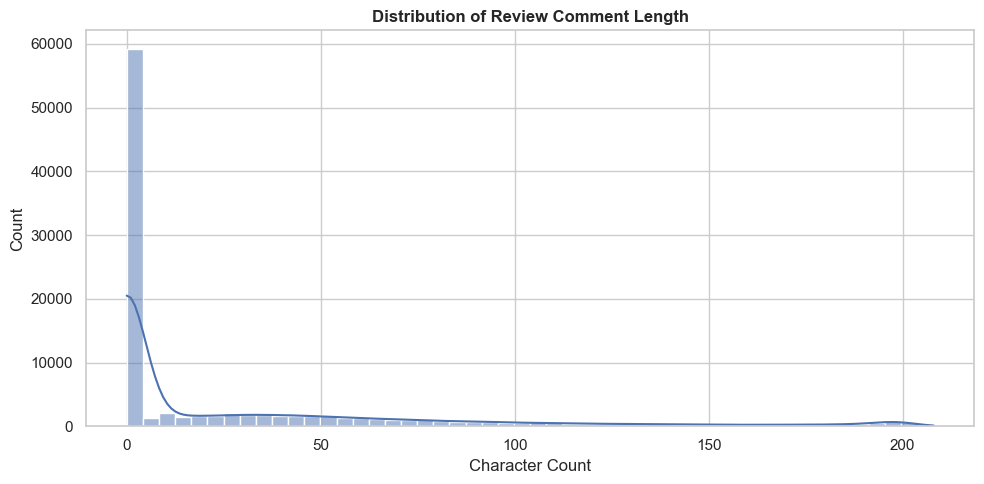

In [ ]:
# Visual Inspection: Distribution of Review Comment Length
plt.figure(figsize=(10, 5))
sns.histplot(temp_reviews_df['comment_length'], bins=50, kde=True)
plt.title("Distribution of Review Comment Length", fontsize=12, fontweight='bold')
plt.xlabel("Character Count")
plt.tight_layout()
plt.show()


#### Sellers data (sellers_df)

In [ ]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


In [ ]:
sellers_df.shape

(3095, 4)

In [ ]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [ ]:
sellers_df.describe(include='object')

C:\Users\mario\AppData\Local\Temp\ipykernel_19076\466393976.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sellers_df.describe(include='object')


,seller_id,seller_city,seller_state
count,3095,3095,3095
unique,3095,611,23
top,3442f8959a84dea7ee197c632cb2df15,sao paulo,SP
freq,1,694,1849


In [ ]:
print("Duplicates: ",sellers_df.duplicated().sum())

Duplicates:  0


In [ ]:
print("Unique Sellers: ", sellers_df['seller_id'].nunique())

Unique Sellers:  3095


In [ ]:
sellers_df['seller_state'].value_counts(normalize=True, dropna=False).mul(100).round(2).head(10)

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
Name: proportion, dtype: float64

In [ ]:
sellers_df.nunique(dropna=True)


seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

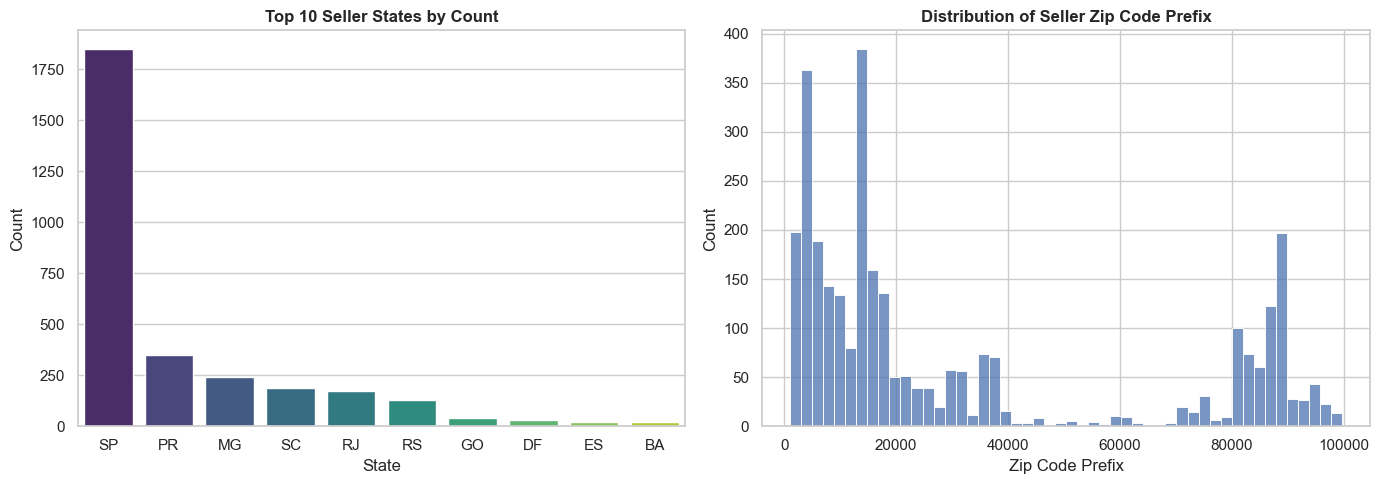

In [ ]:
# Visual Inspection: Top Seller States & Zip Code Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_seller_states = sellers_df['seller_state'].value_counts().head(10)
sns.barplot(x=top_seller_states.index, y=top_seller_states.values, palette='viridis', hue=top_seller_states.index, legend=False, ax=axes[0])
axes[0].set_title("Top 10 Seller States by Count", fontsize=12, fontweight='bold')
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")

sns.histplot(sellers_df['seller_zip_code_prefix'], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Distribution of Seller Zip Code Prefix", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Zip Code Prefix")

plt.tight_layout()
plt.show()


### 4_ Data Relationships & Schema Architecture


In [ ]:
grain_checks = []

def check_single_key(df_name, df, key_col):
    is_unique = df[key_col].nunique() == len(df)
    grain_checks.append({
        "Table": df_name,
        "Check": f"'{key_col}' unique per row?",
        "Result": "PASS - grain confirmed" if is_unique else "FAIL - NOT unique (grain assumption wrong)",
        "Unique Values": df[key_col].nunique(),
        "Total Rows": len(df)
    })

def check_composite_key(df_name, df, key_cols):
    n_unique_combo = df.drop_duplicates(subset=key_cols).shape[0]
    is_unique = n_unique_combo == len(df)
    grain_checks.append({
        "Table": df_name,
        "Check": f"{key_cols} unique per row?",
        "Result": "PASS - grain confirmed" if is_unique else "FAIL - NOT unique (grain assumption wrong)",
        "Unique Values": n_unique_combo,
        "Total Rows": len(df)
    })

def check_not_unique(df_name, df, key_col, reason):
    is_unique = df[key_col].nunique() == len(df)
    grain_checks.append({
        "Table": df_name,
        "Check": f"'{key_col}' NOT unique per row? ({reason})",
        "Result": "PASS - duplicates confirmed as expected" if not is_unique else "UNEXPECTED - it IS unique",
        "Unique Values": df[key_col].nunique(),
        "Total Rows": len(df)
    })


In [ ]:
check_single_key("customers_df", customers_df, "customer_id")
check_not_unique("customers_df", customers_df, "customer_unique_id", "same person can place repeat orders")

In [ ]:
check_single_key("orders_df", orders_df, "order_id")

In [ ]:
check_composite_key("order_items_df", order_items_df, ["order_id", "order_item_id"])
check_not_unique("order_items_df", order_items_df, "order_id", "an order can contain multiple line items")

In [ ]:
check_single_key("products_df", products_df, "product_id")

In [ ]:
check_single_key("sellers_df", sellers_df, "seller_id")

In [ ]:
check_composite_key("order_payments_df", order_payments_df, ["order_id", "payment_sequential"])
check_not_unique("order_payments_df", order_payments_df, "order_id", "an order can be paid via multiple installments/methods")

In [ ]:
check_single_key("reviews_df", reviews_df, "review_id")

In [ ]:
check_not_unique("geolocation_df", geolocation_df, "geolocation_zip_code_prefix", "multiple lat/lng points recorded per zip prefix")

In [ ]:
grain_verification_df = pd.DataFrame(grain_checks)
grain_verification_df

,Table,Check,Result,Unique Values,Total Rows
0,customers_df,'customer_id' unique per row?,PASS - grain confirmed,99441,99441
1,customers_df,'customer_unique_id' NOT unique per row? (same...,PASS - duplicates confirmed as expected,96096,99441
2,orders_df,'order_id' unique per row?,PASS - grain confirmed,99441,99441
3,order_items_df,"['order_id', 'order_item_id'] unique per row?",PASS - grain confirmed,112650,112650
4,order_items_df,'order_id' NOT unique per row? (an order can c...,PASS - duplicates confirmed as expected,98666,112650
5,products_df,'product_id' unique per row?,PASS - grain confirmed,32951,32951
6,sellers_df,'seller_id' unique per row?,PASS - grain confirmed,3095,3095
7,order_payments_df,"['order_id', 'payment_sequential'] unique per ...",PASS - grain confirmed,103886,103886
8,order_payments_df,'order_id' NOT unique per row? (an order can b...,PASS - duplicates confirmed as expected,99440,103886
9,reviews_df,'review_id' unique per row?,FAIL - NOT unique (grain assumption wrong),98410,99224


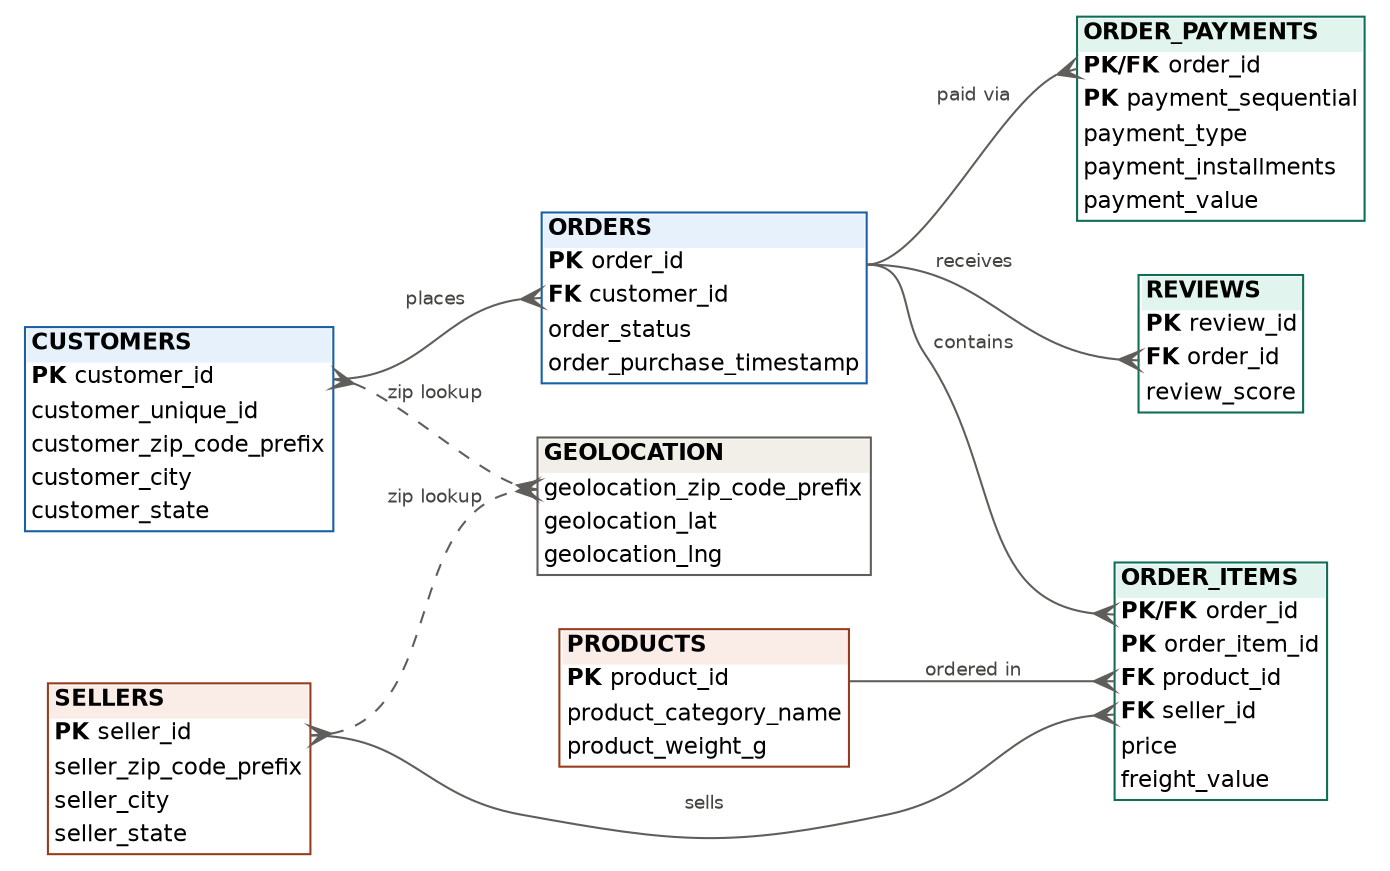

In [ ]:
import base64
from IPython.display import Image, display
_erd_png_b64 = ("...")
display(Image(data=base64.b64decode(_erd_png_b64)))

Understanding primary keys, foreign keys, and dataset grain:
- **`orders_df`**: `order_id` (Primary Key). Grain: 1 row per order.
- **`customers_df`**: `customer_id` (Primary Key), `customer_unique_id` (Unique customer entity). Grain: 1 row per transaction customer ID.
- **`order_items_df`**: Composite (`order_id`, `order_item_id`). Links to `products_df` (`product_id`) and `sellers_df` (`seller_id`). Grain: 1 row per order line item.
- **`order_payments_df`**: Composite (`order_id`, `payment_sequential`). Grain: 1 row per payment method.
- **`reviews_df`**: `review_id` (Primary Key), links to `order_id`. Grain: 1 row per review.
- **`products_df`**: `product_id` (Primary Key), links to `product_category_translation_df`. Grain: 1 row per product.
- **`sellers_df`**: `seller_id` (Primary Key). Grain: 1 row per seller.
- **`geolocation_df`**: `geolocation_zip_code_prefix`. Grain: Zip code coordinates.


### 5_ Data Cleaning & Feature Transformations

In [ ]:
def clean_data(data: dict) -> dict:
    data = {k: v.copy() for k, v in data.items()}

    # orders: convert date columns + make sure order_id is unique
    date_cols = ["order_purchase_timestamp", "order_approved_at","order_delivered_carrier_date", "order_delivered_customer_date","order_estimated_delivery_date"]
    for col in date_cols:
        data["orders"][col] = pd.to_datetime(data["orders"][col], errors="coerce")
    data["orders"] = data["orders"].drop_duplicates(subset="order_id")

    # customers: drop duplicates
    data["customers"] = data["customers"].drop_duplicates(subset="customer_id")

    # sellers: drop duplicates
    data["sellers"] = data["sellers"].drop_duplicates(subset="seller_id")

    # products: fill missing values + merge in the English translation
    products = data["products"]
    products["product_category_name"] = products["product_category_name"].fillna("unknown")
    products = products.merge(data["category_translation"], on="product_category_name", how="left")
    products["product_category_name_english"] = products["product_category_name_english"].fillna(products["product_category_name"])

    # dimensions/weight: fill with the median of the same category (more accurate than a global fill)
    dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
    for col in dim_cols:
        products[col] = products.groupby("product_category_name_english")[col].transform(lambda s: s.fillna(s.median()))
        products[col] = products[col].fillna(products[col].median())
    data["products"] = products.drop_duplicates(subset="product_id")

    # order_items: make sure (order_id + order_item_id) is unique
    data["order_items"] = data["order_items"].drop_duplicates(subset=["order_id", "order_item_id"])
    data["order_items"]["shipping_limit_date"] = pd.to_datetime(data["order_items"]["shipping_limit_date"], errors="coerce")

    # order_payments: simple cleanup
    data["order_payments"] = data["order_payments"].dropna(subset=["order_id"])

    # reviews: replace missing comments with an empty string instead of NaN
    reviews = data["reviews"]
    reviews["review_comment_title"] = reviews["review_comment_title"].fillna("")
    reviews["review_comment_message"] = reviews["review_comment_message"].fillna("")
    reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
    reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
    data["reviews"] = reviews

    return data

In [ ]:
import os

raw_data_dict = {
    "orders": orders_df,
    "customers": customers_df,
    "sellers": sellers_df,
    "products": products_df,
    "category_translation": product_category_translation_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "reviews": reviews_df,
}

cleaned_data = clean_data(raw_data_dict)

orders_df_cleaned = cleaned_data["orders"]
customers_df_cleaned = cleaned_data["customers"]
sellers_df_cleaned = cleaned_data["sellers"]
products_df_cleaned = cleaned_data["products"]
order_items_df_cleaned = cleaned_data["order_items"]
order_payments_df_cleaned = cleaned_data["order_payments"]
reviews_df_cleaned = cleaned_data["reviews"]

CLEANED_DATA_DIR = r"D:\courses\Data Analytics\NTI\Final Project"
os.makedirs(CLEANED_DATA_DIR, exist_ok=True)

cleaned_files = {
    "orders_cleaned.csv": orders_df_cleaned,
    "customers_cleaned.csv": customers_df_cleaned,
    "sellers_cleaned.csv": sellers_df_cleaned,
    "products_cleaned.csv": products_df_cleaned,
    "order_items_cleaned.csv": order_items_df_cleaned,
    "order_payments_cleaned.csv": order_payments_df_cleaned,
    "reviews_cleaned.csv": reviews_df_cleaned,
}

for filename, df in cleaned_files.items():
    df.to_csv(os.path.join(CLEANED_DATA_DIR, filename), index=False)

print(f"Saved {len(cleaned_files)} cleaned files to: {CLEANED_DATA_DIR}")
for filename, df in cleaned_files.items():
    print(f"  {filename}: {len(df):,} rows")

Saved 7 cleaned files to: D:\courses\Data Analytics\NTI\Final Project
  orders_cleaned.csv: 99,441 rows
  customers_cleaned.csv: 99,441 rows
  sellers_cleaned.csv: 3,095 rows
  products_cleaned.csv: 32,951 rows
  order_items_cleaned.csv: 112,650 rows
  order_payments_cleaned.csv: 103,886 rows
  reviews_cleaned.csv: 99,224 rows


### 7_ Exploratory Data Analysis (EDA)

### 10_ RFM Analysis — Customer Segmentation Features

### 11_ K-Means Customer Segmentation

### 12_ Cluster Exploration & Profiling

### 13_ Predictive Analytics — Sales & Order Forecasting